<a href="https://colab.research.google.com/github/gaelBZH/NumericalMethods/blob/main/Laboratory5/Laboratory_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratory 5 🌍
Gaël Kerninon
---


In [27]:
import numpy as np
import matplotlib.pyplot as plt

## Exercise 1 🖋️

In [28]:
# function
def f(x):
    return x * np.sin(4*x)

# derivative: f'(x) = sin(4x) + 4x cos(4x)
def g(x):
    return np.sin(4*x) + 4*x*np.cos(4*x)

# Newton method
def newton_method(f, g, x0, tol=1e-8, max_iter=100):
    x = x0

    for i in range(max_iter):
        if abs(g(x)) < 1e-12:
            print("Derivative too close to zero.")
            break

        x_new = x - f(x)/g(x)

        if abs(x_new - x) < tol:
            return x_new, i + 1

        x = x_new

    return x, max_iter

Derivative too close to zero.


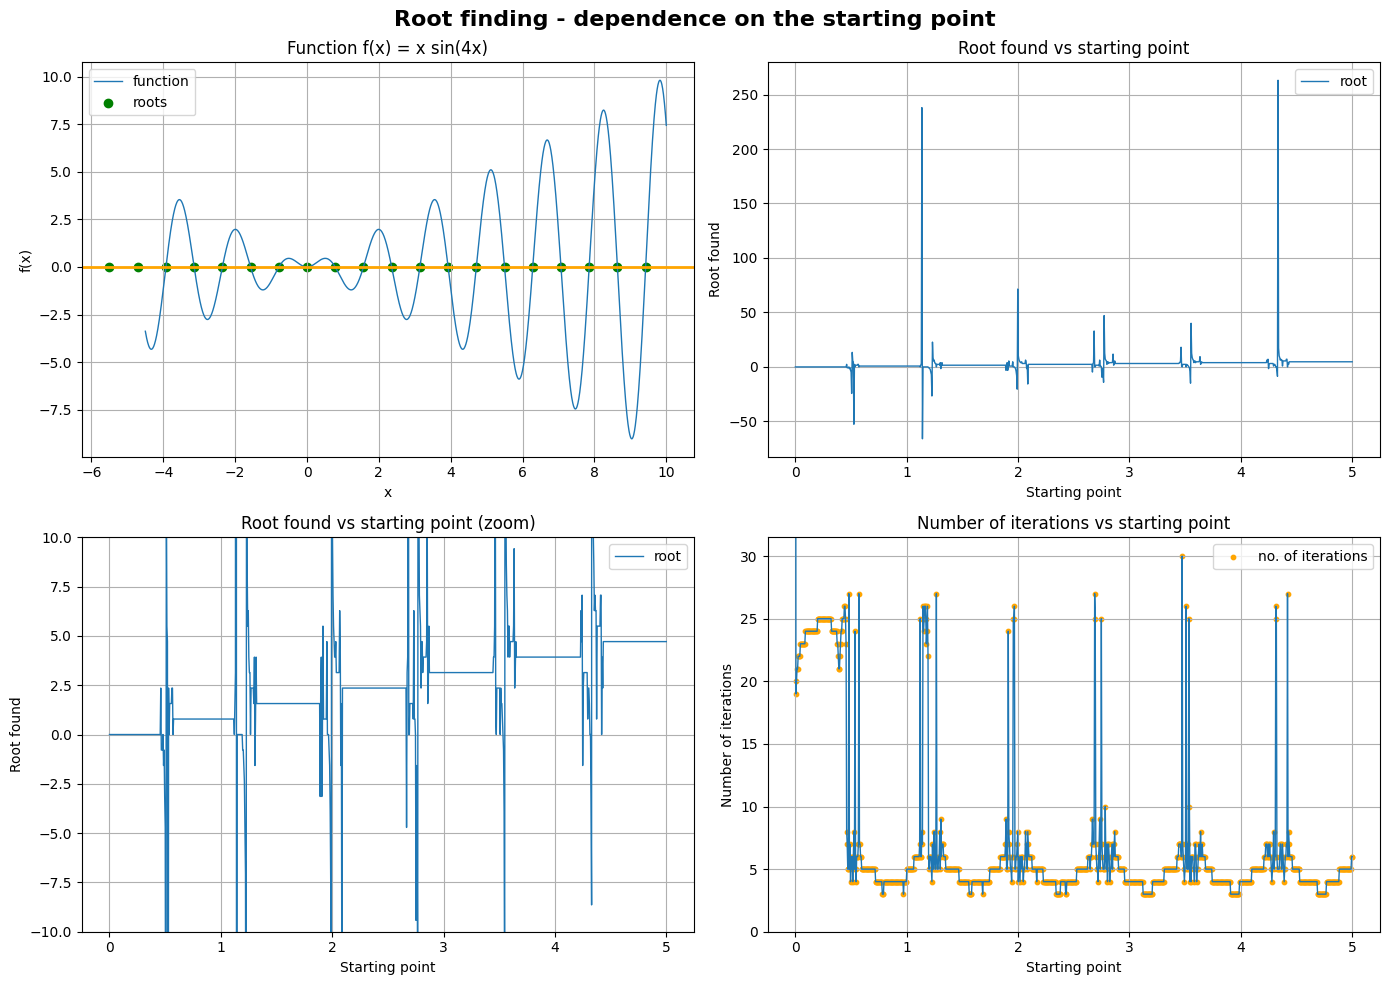

In [29]:
# ======================== Init ========================
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Root finding - dependence on the starting point", fontsize=16, fontweight='bold')
starting_points = np.linspace(0, 5, 1000)
roots = []
iteration_counts = []
for x0 in starting_points:
    root, iters = newton_method(f, g, x0)
    roots.append(root)
    iteration_counts.append(iters)
roots = np.array(roots)
iteration_counts = np.array(iteration_counts)


# ======================== GRAPH 1 ========================
x = np.linspace(-4.5, 10, 2000)
axs[0, 0].plot(x, f(x), lw=1, label="function")
axs[0, 0].axhline(0, color='orange', lw=2)

k = np.arange(-20, 40)
roots_theo = k * np.pi / 4
roots_theo = roots_theo[(roots_theo >= -6) & (roots_theo <= 10)]

axs[0, 0].scatter(roots_theo, np.zeros_like(roots_theo), color='green', label="roots")
axs[0, 0].set_xlabel("x")
axs[0, 0].set_ylabel("f(x)")
axs[0, 0].set_title("Function f(x) = x sin(4x)")
axs[0, 0].legend()
axs[0, 0].grid(True)

# ======================== GRAPH 2 ========================
axs[0, 1].plot(starting_points, roots, lw=1, label="root", color='tab:blue')
axs[0, 1].set_xlabel("Starting point")
axs[0, 1].set_ylabel("Root found")
axs[0, 1].set_title("Root found vs starting point")
axs[0, 1].legend()
axs[0, 1].grid(True)

# ======================== GRAPH 3 ========================
axs[1, 0].plot(starting_points, roots, lw=1, label="root", color='tab:blue')
axs[1, 0].set_ylim(-10, 10)
axs[1, 0].set_xlabel("Starting point")
axs[1, 0].set_ylabel("Root found")
axs[1, 0].set_title("Root found vs starting point (zoom)")
axs[1, 0].legend()
axs[1, 0].grid(True)

# ======================== GRAPH 4 ========================
axs[1, 1].plot(starting_points, iteration_counts, lw=1, color='tab:blue')
axs[1, 1].scatter(starting_points, iteration_counts, color='orange', s=10, label="no. of iterations")
axs[1, 1].set_ylim(0, 31.5)
axs[1, 1].set_xlabel("Starting point")
axs[1, 1].set_ylabel("Number of iterations")
axs[1, 1].set_title("Number of iterations vs starting point")
axs[1, 1].legend()
axs[1, 1].grid(True)

# Print
plt.tight_layout()
plt.show()

## Exercise 2 🖋️

For the given system of equations:

1. $x^2 + y^2 + z^2 = 2$
2. $x^2 + y^2 = 1$
3. $x^2 = y$

We must first rewrite these equations in the form $\mathbf{F}(x, y, z) = 0$ to define the vector function and calculate its Jacobian matrix.

### Vector function $\mathbf{F}(x, y, z)$ :

$$F(x, y, z) = \begin{bmatrix} x^2 + y^2 + z^2 - 2 \\ x^2 + y^2 - 1 \\ x^2 - y \end{bmatrix}$$

### Jacobian matrix $\mathbf{J}(x, y, z)$ :

\begin{equation}
    J(x, y, z) = \begin{bmatrix}
        \frac{\partial f_1}{\partial x} & \frac{\partial f_1}{\partial y} & \frac{\partial f_1}{\partial z} \\[0.5em]
        \frac{\partial f_2}{\partial x} & \frac{\partial f_2}{\partial y} & \frac{\partial f_2}{\partial z} \\[0.5em]
        \frac{\partial f_3}{\partial x} & \frac{\partial f_3}{\partial y} & \frac{\partial f_3}{\partial z}
    \end{bmatrix} = \begin{bmatrix}
        2x & 2y & 2z \\
        2x & 2y & 0 \\
        2x & -1 & 0
    \end{bmatrix}
\end{equation}


## Exercise 3 🖋️

In [30]:
import numpy as np

# System of Equations
def function_sys(xyz):
    x, y, z = xyz
    return [
        x**2 + y**2 + z**2 - 2,
        x**2 + y**2 - 1,
        x**2 - y
    ]

# Jacobianne Matrix
def jacobian_sys(xyz):
    x, y, z = xyz
    return [
        [2*x, 2*y, 2*z],
        [2*x, 2*y,   0],
        [2*x,  -1,   0]
    ]

# Newton Method
def iterative_newton(fun, x_init, jacobian):
    max_iter = 50
    epsilon = 1e-8
    x_last = np.array(x_init)

    for k in range(max_iter):
        J = np.array(jacobian(x_last))
        F = np.array(fun(x_last))

        # System Solve
        diff = np.linalg.solve(J, -F)
        x_last = x_last + diff

        # Stopping Criteria
        if np.linalg.norm(diff) < epsilon:
            print(f'Convergence ! NB Iretations: {k}')
            break
    else:
        print('Not converged')

    return x_last

# Solve System
initial_guess = [0.8, 0.8, 1.2]
x_sol = iterative_newton(function_sys, initial_guess, jacobian_sys)

print('Solution [x, y, z]:', x_sol)
print('Residual F(sol):', np.round(function_sys(x_sol), 10))

Convergence ! NB Iretations: 4
Solution [x, y, z]: [0.78615138 0.61803399 1.        ]
Residual F(sol): [ 0. -0.  0.]
